Número real de clusters a generar: 19


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20992\2572771025.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, s=2, cmap='viridis')


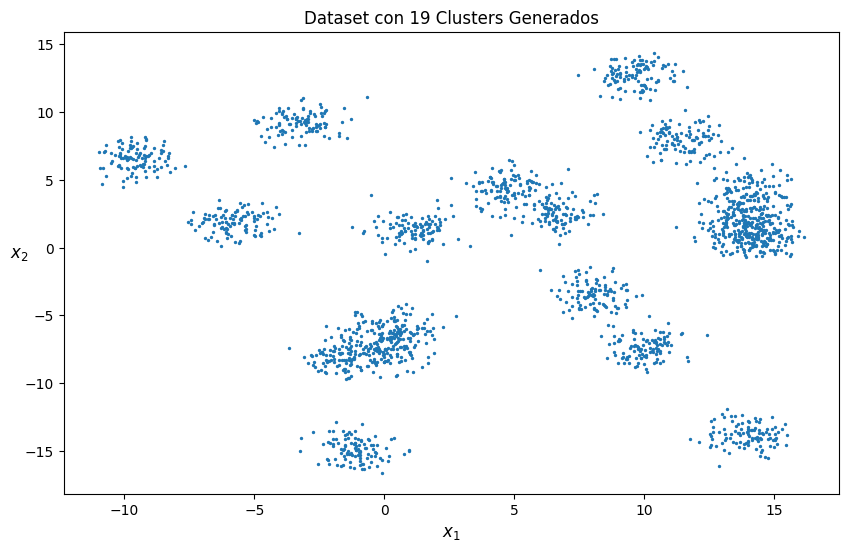

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib as mpl

# 1. Definir cantidad de clusters aleatorios entre 1 y 20
n_clusters_true = np.random.randint(1, 21)
print(f"Número real de clusters a generar: {n_clusters_true}")

# 2. Generar centros aleatorios con "distancia importante"
# Multiplicamos por 15 para esparcirlos en un plano amplio
blob_centers = np.random.uniform(-15, 15, (n_clusters_true, 2))
blob_std = 0.8  # Desviación estándar baja para que se vean bien separados

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

# Función básica para graficar los puntos
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=2, cmap='viridis')
    plt.xlabel("$x_1$", fontsize=12)
    plt.ylabel("$x_2$", fontsize=12, rotation=0)

plt.figure(figsize=(10, 6))
plot_clusters(X)
plt.title(f"Dataset con {n_clusters_true} Clusters Generados")
plt.show()

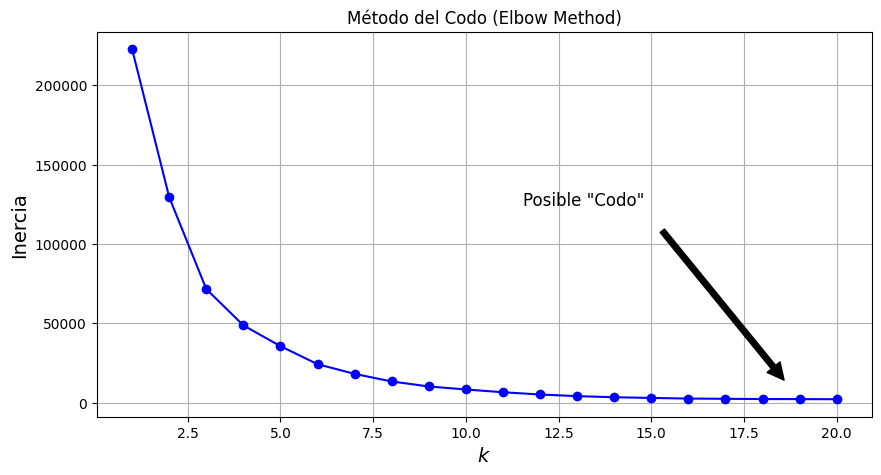

In [2]:
# Probar K desde 1 hasta 20 (o un poco más para ver el comportamiento)
k_range = range(1, 21)
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X) for k in k_range]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo (Elbow Method)")
plt.annotate('Posible "Codo"',
             xy=(n_clusters_true, inertias[n_clusters_true-1]),
             xytext=(0.55, 0.55),
             textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.1),
             fontsize=12)
plt.grid(True)
plt.show()

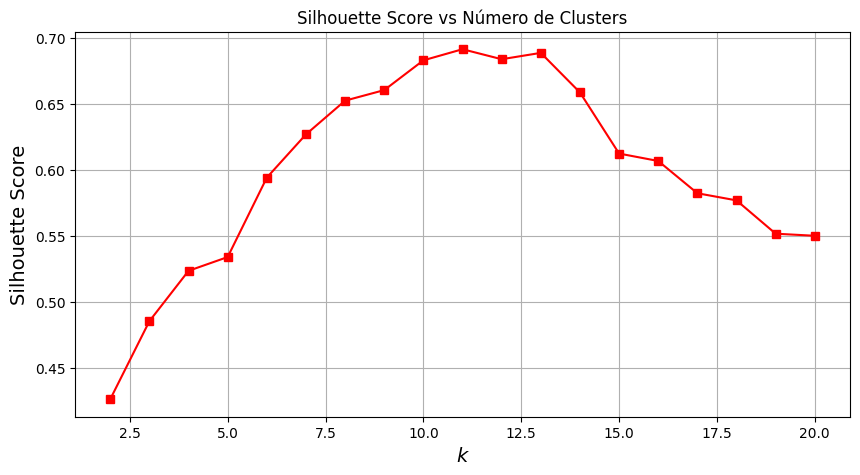

El número óptimo de clusters según Silhouette Score es: 11


In [3]:
# El silhouette score requiere al menos 2 clusters para calcularse
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(10, 5))
plt.plot(range(2, 21), silhouette_scores, "rs-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters")
plt.grid(True)
plt.show()

# Identificar el K óptimo según Silhouette
k_optimo_idx = np.argmax(silhouette_scores) + 2
print(f"El número óptimo de clusters según Silhouette Score es: {k_optimo_idx}")

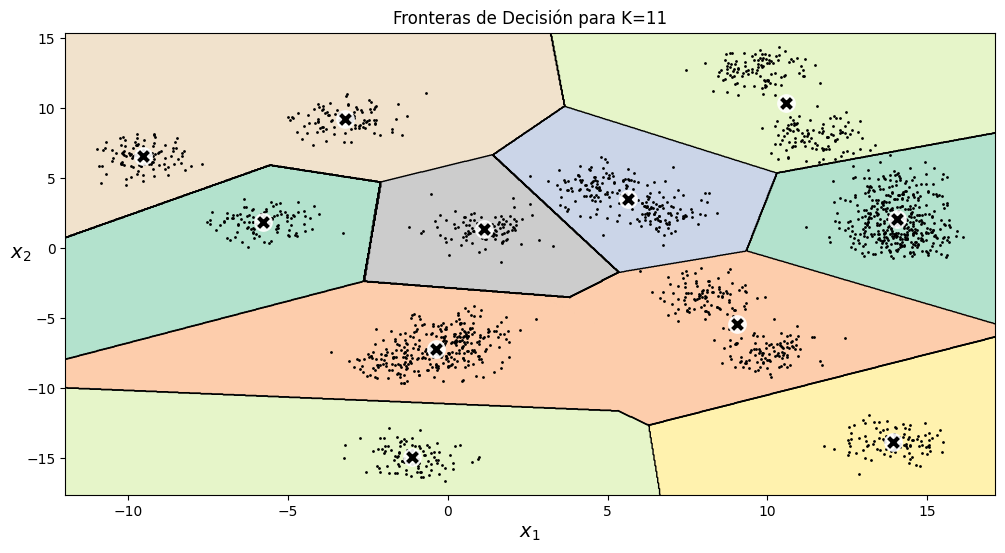

In [4]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=3,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X):
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 1000),
                         np.linspace(mins[1], maxs[1], 1000))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors='k')
    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

# Entrenar con el K detectado como óptimo
kmeans_final = KMeans(n_clusters=k_optimo_idx, n_init=10, random_state=42)
kmeans_final.fit(X)

plt.figure(figsize=(12, 6))
plot_decision_boundaries(kmeans_final, X)
plt.title(f"Fronteras de Decisión para K={k_optimo_idx}")
plt.show()